# A first look at CIFAR-100

**Goal:** load the images, understand the labels, and record a few observations before we build a model.

Work through the notebook from top to bottom, or choose **Kernel → Restart Kernel and Run All Cells**. The first run downloads about **169 MB**; later runs reuse the cached file. No GPU is needed.

We explore only the **training set** here. Leave the official test set untouched for later evaluation. Corrupted images, SVHN, calibration, and modeling will come later.

Dataset: [CIFAR-100, University of Toronto](https://www.cs.toronto.edu/~kriz/cifar.html), by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. Images have a **fine label** (one of 100 classes) and a **coarse label** (one of 20 broader groups).


## 1. Import our tools

NumPy handles image arrays, pandas makes tables, and Matplotlib draws the plots.
The remaining imports are part of Python and handle the download and archive.


In [1]:
from pathlib import Path
import hashlib
import pickle
import tarfile
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


## 2. Download once, then load the training data

The archive is cached in `.cache/sdm-vision-reliability` under your home directory, outside the Git repository. Change `DATA_DIR` if you already keep data somewhere else.

We check the archive against the [checksum used by torchvision](https://github.com/pytorch/vision/blob/v0.25.0/torchvision/datasets/cifar.py) before reading its pickle files. Only use this verified archive. If a download is interrupted, the next run downloads it again. A slow first download is normal; you can also put the official `cifar-100-python.tar.gz` file in `DATA_DIR` yourself.


In [2]:
DATA_DIR = Path.home() / ".cache" / "sdm-vision-reliability"
DATA_DIR.mkdir(parents=True, exist_ok=True)
archive_path = DATA_DIR / "cifar-100-python.tar.gz"
url = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"
expected_md5 = "eb9058c3a382ffc7106e4002c42a8d85"

if not archive_path.exists():
    print("Downloading CIFAR-100 (about 169 MB)...")
    temporary_path = archive_path.with_suffix(".download")
    urlretrieve(url, temporary_path)
    temporary_path.replace(archive_path)

with archive_path.open("rb") as file:
    checksum = hashlib.file_digest(file, "md5").hexdigest()
if checksum != expected_md5:
    raise ValueError("The archive checksum does not match. Remove the cached archive and rerun this cell.")
print("Archive verified. Ready to load training images.")


Archive verified. Ready to load training images.


In [3]:
with tarfile.open(archive_path, "r:gz") as archive:
    training = pickle.load(archive.extractfile("cifar-100-python/train"), encoding="latin1")
    metadata = pickle.load(archive.extractfile("cifar-100-python/meta"), encoding="latin1")

# The archive stores each image as three flattened color channels.
# Rearrange it to (image, height, width, color channel) for plotting.
images = training["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
fine_labels = np.array(training["fine_labels"])
coarse_labels = np.array(training["coarse_labels"])
class_names = metadata["fine_label_names"]
group_names = metadata["coarse_label_names"]

labels = pd.DataFrame({
    "class": np.array(class_names)[fine_labels],
    "group": np.array(group_names)[coarse_labels],
})
labels.head()


,class,group
0,cattle,large_omnivores_and_herbivores
1,dinosaur,reptiles
2,apple,fruit_and_vegetables
3,boy,people
4,aquarium_fish,fish


## 3. What did we load?

Each image is **32 × 32 pixels**, with red, green, and blue channels. Pixel values are integers from 0 (dark) to 255 (bright). We keep them in their original form for this first look.


In [4]:
pd.Series({
    "training images": len(images),
    "image shape (height, width, channels)": images.shape[1:],
    "pixel type": str(images.dtype),
    "smallest pixel value": int(images.min()),
    "largest pixel value": int(images.max()),
    "classes": labels["class"].nunique(),
    "broader groups": labels["group"].nunique(),
}, name="CIFAR-100 training set").to_frame()


,CIFAR-100 training set
training images,50000
"image shape (height, width, channels)","(32, 32, 3)"
pixel type,uint8
smallest pixel value,0
largest pixel value,255
classes,100
broader groups,20


## 4. See some images and their names

The fixed seed makes this gallery repeatable. Try changing `SEED` and rerunning this cell to see another sample. These tiny images are enlarged without smoothing so we can see their actual pixels.


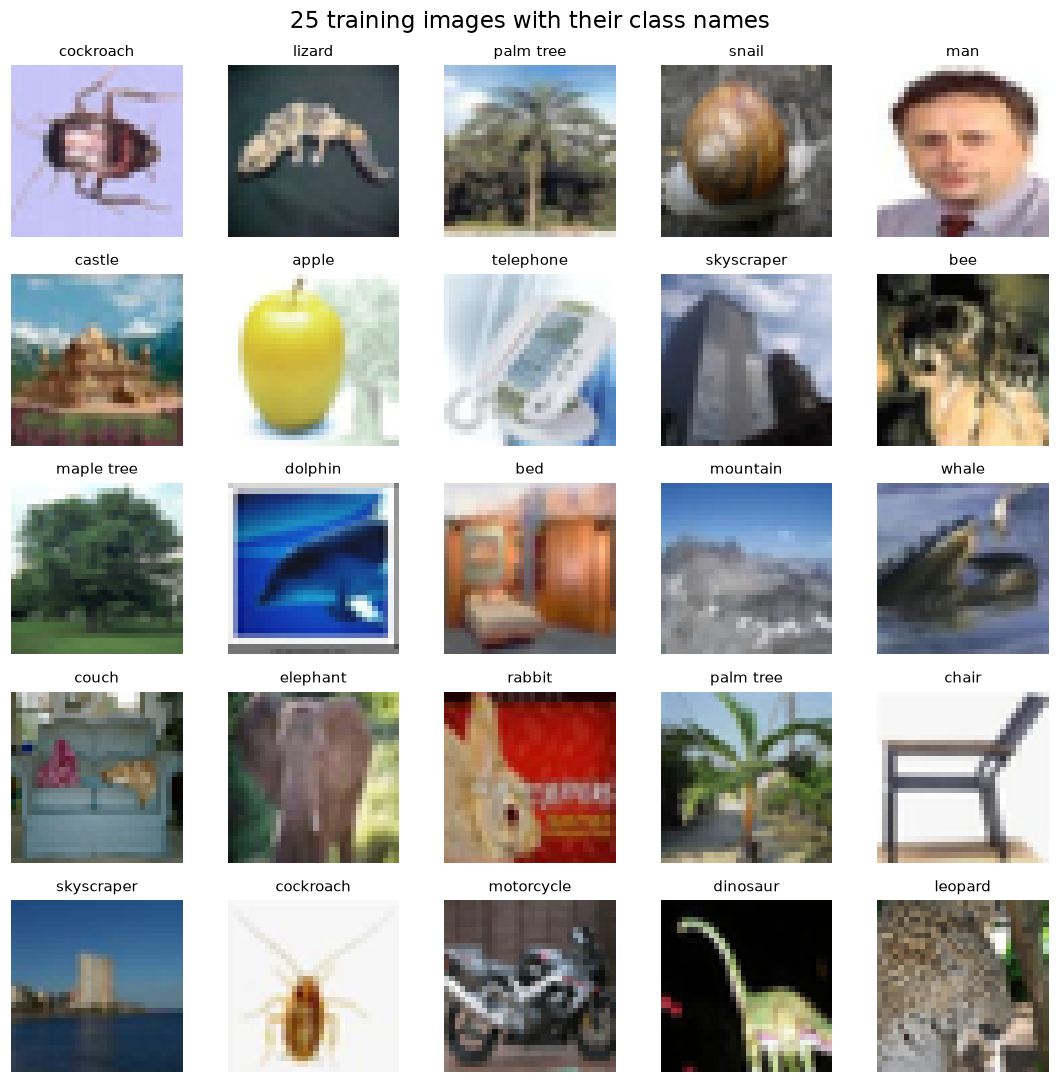

In [5]:
sample_indices = np.random.default_rng(SEED).choice(len(images), size=25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, index in zip(axes.flat, sample_indices):
    ax.imshow(images[index], interpolation="nearest")
    ax.set_title(labels.loc[index, "class"].replace("_", " "), fontsize=10)
    ax.axis("off")
fig.suptitle("25 training images with their class names", fontsize=15)
plt.tight_layout()
plt.show()


## 5. Explore one class

Run the next cell to see the available names. Then replace `CLASS_NAME` in the gallery cell with a name that interests you.


In [6]:
print(", ".join(class_names))


apple, aquarium_fish, baby, bear, beaver, bed, bee, beetle, bicycle, bottle, bowl, boy, bridge, bus, butterfly, camel, can, castle, caterpillar, cattle, chair, chimpanzee, clock, cloud, cockroach, couch, crab, crocodile, cup, dinosaur, dolphin, elephant, flatfish, forest, fox, girl, hamster, house, kangaroo, keyboard, lamp, lawn_mower, leopard, lion, lizard, lobster, man, maple_tree, motorcycle, mountain, mouse, mushroom, oak_tree, orange, orchid, otter, palm_tree, pear, pickup_truck, pine_tree, plain, plate, poppy, porcupine, possum, rabbit, raccoon, ray, road, rocket, rose, sea, seal, shark, shrew, skunk, skyscraper, snail, snake, spider, squirrel, streetcar, sunflower, sweet_pepper, table, tank, telephone, television, tiger, tractor, train, trout, tulip, turtle, wardrobe, whale, willow_tree, wolf, woman, worm


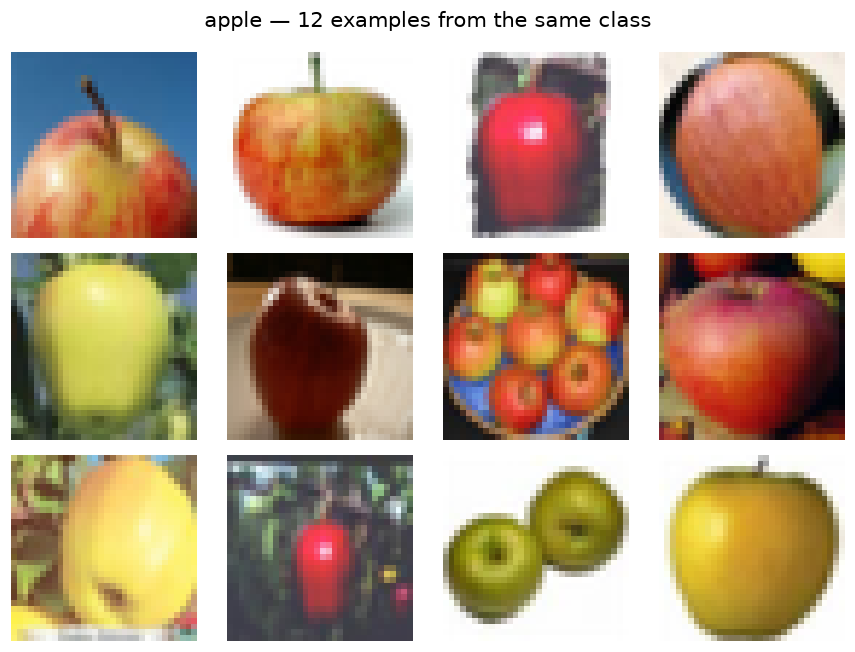

In [7]:
CLASS_NAME = "apple"

if CLASS_NAME not in class_names:
    raise ValueError("Choose a class name from the list above.")
class_indices = labels.index[labels["class"] == CLASS_NAME].to_numpy()
chosen = np.random.default_rng(SEED).choice(class_indices, size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax, index in zip(axes.flat, chosen):
    ax.imshow(images[index], interpolation="nearest")
    ax.axis("off")
fig.suptitle(f"{CLASS_NAME.replace('_', ' ')} — 12 examples from the same class", fontsize=14)
plt.tight_layout()
plt.show()


## 6. Are the labels balanced?

Count images in each fine class and each broader group. A balanced dataset has the same number of examples per label; that does not mean every class is equally easy to recognize.


In [8]:
class_counts = labels.groupby(["group", "class"]).size().rename("images").reset_index()
display(class_counts.head(10))
print(f"Images per class: {class_counts['images'].min()} to {class_counts['images'].max()}")
print(f"All {len(class_counts)} classes have equal counts: {class_counts['images'].nunique() == 1}")


,group,class,images
0,aquatic_mammals,beaver,500
1,aquatic_mammals,dolphin,500
2,aquatic_mammals,otter,500
3,aquatic_mammals,seal,500
4,aquatic_mammals,whale,500
5,fish,aquarium_fish,500
6,fish,flatfish,500
7,fish,ray,500
8,fish,shark,500
9,fish,trout,500


Images per class: 500 to 500
All 100 classes have equal counts: True


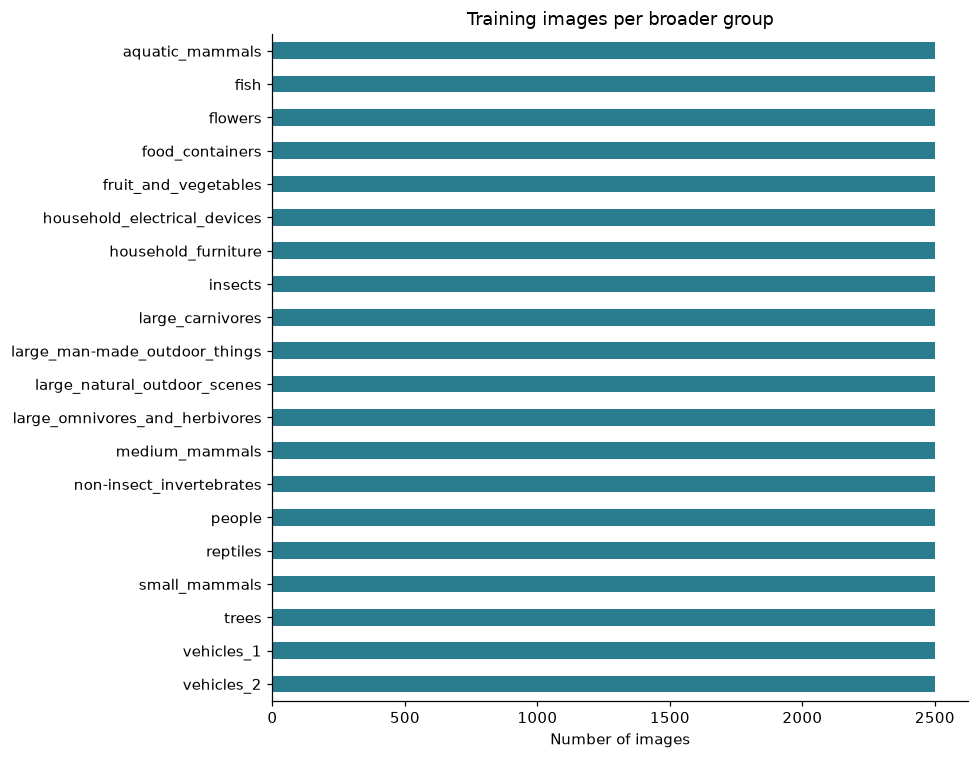

In [9]:
group_counts = labels["group"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 7))
group_counts.plot.barh(ax=ax, color="#287c8e")
ax.set_title("Training images per broader group")
ax.set_xlabel("Number of images")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
# Data integrity and label hierarchy

assert images.shape == (50000, 32, 32, 3)
assert len(labels) == len(images)
assert labels["class"].isin(class_names).all()
assert labels["group"].isin(group_names).all()

class_group_counts = labels.groupby("group")["class"].nunique()
assert (class_group_counts == 5).all()
image_hashes = pd.Series([hashlib.md5(image.tobytes()).hexdigest() for image in images])
integrity_summary = pd.Series({
    "images with expected shape": images.shape == (50000, 32, 32, 3),
    "classes with 500 images": (class_counts["images"] == 500).all(),
    "coarse groups": labels["group"].nunique(),
    "fine classes per coarse group": int(class_group_counts.iloc[0]),
    "exact duplicate images": image_hashes.duplicated().sum(),
}, name="Integrity check").to_frame()
display(integrity_summary)

duplicate_labels = (
    labels.assign(image_hash=image_hashes)
    .groupby("image_hash")
    .agg(classes=("class", lambda values: ", ".join(sorted(set(values)))), copies=("class", "size"))
    .query("copies > 1")
    .sort_values("classes")
)
display(duplicate_labels)


,Integrity check
images with expected shape,True
classes with 500 images,True
coarse groups,20
fine classes per coarse group,5
exact duplicate images,14


,classes,copies
image_hash,,
277ae8260c1ae1c5c1a9102d5599134f,aquarium_fish,2
73bd131bb0ce90be0b79e03abdd3f6f9,aquarium_fish,2
88418eb5c3f7a5161f2a81bf3f74685b,aquarium_fish,2
9a96c073b2eca1e6919cca8f74cfb482,aquarium_fish,2
dedc9a2b51ad88a5bf533c00ccb952fe,aquarium_fish,2
d04796ba3a4f568540aad3bdd93a897f,"baby, girl",2
23eec6fcc43bd95b07671a463bf09a98,"crab, spider",2
b3daad16fb38b0b0e0c5a118843aa3b7,"mouse, shrew",2
446a3d1829afe00a2d6259e985e057a5,"otter, seal",2


,mean_brightness,mean_contrast,red,green,blue
class,,,,,
aquarium_fish,92.0,55.8,101.3,95.0,79.6
forest,94.5,44.8,100.5,102.7,80.3
poppy,97.0,65.5,136.9,94.0,60.2
shark,97.3,57.6,64.2,101.9,126.0
chimpanzee,97.6,55.9,102.4,100.7,89.8
tulip,97.7,61.8,125.2,95.8,72.3
possum,99.3,50.8,107.7,100.9,89.3
mushroom,99.5,53.3,111.7,105.5,81.2
porcupine,103.8,46.1,112.5,107.8,91.0


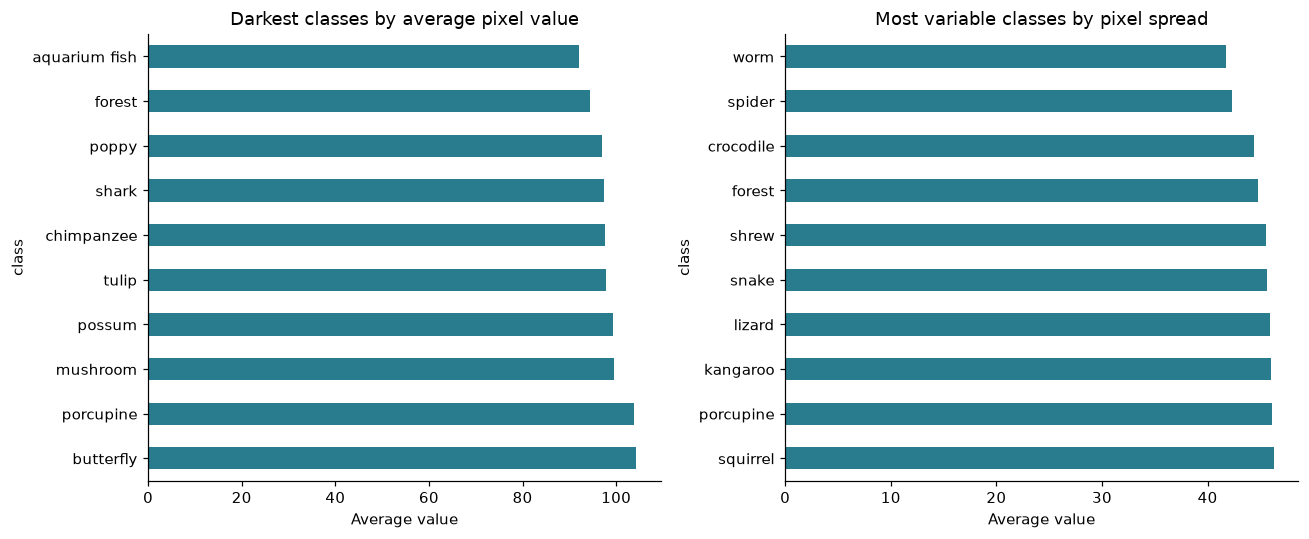

In [11]:
# How much do image statistics vary by class?

image_stats = pd.DataFrame({
    "brightness": images.mean(axis=(1, 2, 3)),
    "contrast": images.std(axis=(1, 2, 3)),
    "red": images[..., 0].mean(axis=(1, 2)),
    "green": images[..., 1].mean(axis=(1, 2)),
    "blue": images[..., 2].mean(axis=(1, 2)),
})
class_stats = labels.join(image_stats).groupby("class").agg(
    mean_brightness=("brightness", "mean"),
    mean_contrast=("contrast", "mean"),
    red=("red", "mean"),
    green=("green", "mean"),
    blue=("blue", "mean"),
)
display(class_stats.sort_values("mean_brightness").head(10).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, column, title in zip(
    axes,
    ["mean_brightness", "mean_contrast"],
    ["Darkest classes by average pixel value", "Most variable classes by pixel spread"],
):
    values = class_stats[column].sort_values().head(10)
    values.index = values.index.str.replace("_", " ")
    values.plot.barh(ax=ax, color="#287c8e")
    ax.set_title(title)
    ax.set_xlabel("Average value")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [12]:
# A simple nearest-centroid baseline
# Use pooled pixels as lightweight features; keep the official test set untouched.
pooled_images = images.reshape(-1, 8, 4, 8, 4, 3).mean(axis=(2, 4))
features = (pooled_images / 255.0).reshape(len(images), -1).astype(np.float32)

rng = np.random.default_rng(SEED)
train_mask = np.zeros(len(images), dtype=bool)
for class_id in range(len(class_names)):
    class_indices = np.flatnonzero(fine_labels == class_id)
    rng.shuffle(class_indices)
    train_mask[class_indices[:400]] = True
validation_mask = ~train_mask

centroids = np.vstack([
    features[train_mask & (fine_labels == class_id)].mean(axis=0)
    for class_id in range(len(class_names))
])
validation_features = features[validation_mask]
squared_distances = (validation_features ** 2).sum(axis=1, keepdims=True)
squared_distances = squared_distances + (centroids ** 2).sum(axis=1)
squared_distances = squared_distances - 2 * validation_features @ centroids.T
predicted_labels = squared_distances.argmin(axis=1)
validation_accuracy = (predicted_labels == fine_labels[validation_mask]).mean()

print(f"Training examples: {train_mask.sum():,}")
print(f"Validation examples: {validation_mask.sum():,}")
print(f"Nearest-centroid validation accuracy: {validation_accuracy:.2%}")


Training examples: 40,000
Validation examples: 10,000
Nearest-centroid validation accuracy: 9.93%
